In [73]:
#importing everything needed for the notebook to run
import numpy as np
import matplotlib.pyplot as plt
import random

#datasets are being used from tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical

In [74]:
#finding how many images the data is split for training and testing, and the image size
(X_train,y_train),(X_test,y_test) = mnist.load_data()

print("X_train shape",X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


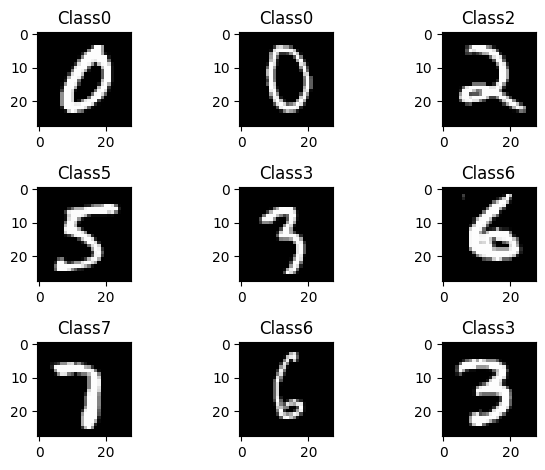

In [75]:
#this plots the images from the training set using matplotlib
for i in range(9):
  plt.subplot(3,3,i+1)
  num = random.randint(0, len(X_train))
  plt.imshow(X_train[num],cmap='gray', interpolation='none')
  plt.title("Class{}".format(y_train[num]))

plt.tight_layout()

In [76]:
#reshaping the 28 x 28 matrices into 784-length vectors
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#changing the integers into 32-bit floating numbers
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

#normalising data
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (60000, 784)
Testing matrix shape (10000, 784)


In [77]:
#number of unique digits
nb_classes = 10

Y_train = to_categorical(y_train, nb_classes)
Y_test = to_categorical(y_test, nb_classes)

In [78]:
#adding the Sequential model
model = Sequential()

In [79]:
#each node (the 512 units) will apply some weight and bias from each input vector
model.add(Dense(512, input_shape=(784,)))


In [80]:
#activation checks the new value of the node
model.add(Activation('relu'))

In [81]:
#dropout is added to minimise overfitting of the data
model.add(Dropout(0.2))

In [82]:
#changing the inputs to the nodes from 784 to 512, so it receives 512 inputs from the 512-node layer
model.add(Dense(512), Activation('relu'))
model.add(Dropout(0.2))

In [83]:
model.add(Dense(10), Activation('softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
#using Adam optimizer for learning
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

In [85]:
#training the model and finding a good batch size
model.fit(X_train, Y_train,
          batch_size=18, epochs=5,
          verbose=1)

Epoch 1/5
3334/3334 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.2512 - loss: 8.9386
Epoch 2/5
3334/3334 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.2598 - loss: 9.0646
Epoch 3/5
3334/3334 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.1735 - loss: 9.4719
Epoch 4/5
3334/3334 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.1743 - loss: 9.4694
Epoch 5/5
3334/3334 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.1727 - loss: 9.4705


In [86]:
#evaluating the model's accuracy on the test data
score = model.evaluate(X_test, Y_test)
print('Test score:', score[0])
print('Test accuracy;', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1845 - loss: 9.4903
Test score: 9.490323066711426
Test accuracy; 0.18449999392032623


In [111]:
#inspecting the output
predicted_classes = np.argmax(model.predict(X_test), axis=-1)
correct_indices = np.where(predicted_classes == y_test)[0]
incorrect_indices = np.where(predicted_classes != y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


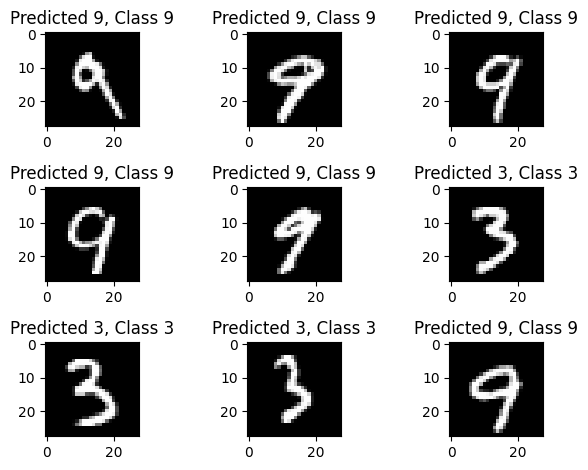

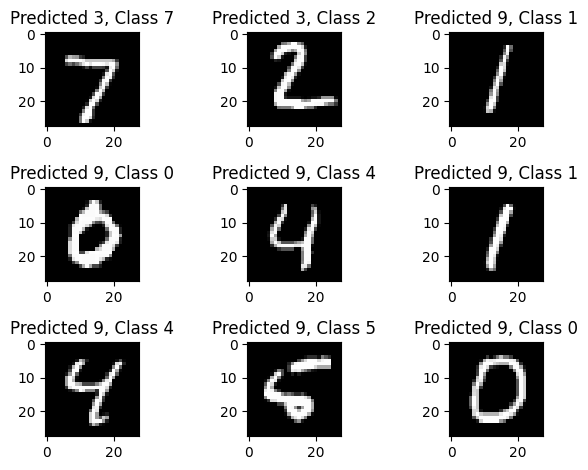

In [112]:
#displays the output
plt.figure()
for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[correct].reshape(28,28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[correct], y_test[correct]))

plt.tight_layout()

plt.figure()

for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[incorrect].reshape(28, 28), cmap='gray', interpolation='none')
    plt.title("Predicted {}, Class {}".format(predicted_classes[incorrect], y_test[incorrect]))


plt.tight_layout()